# House Price Prediction

This dataset contains information that will be used to predict the prices of houses in california

# Objectives

* Develop a regression model using RandomTreeForest Regression Model
* Apply this model on real world dataset

## Data Preprocessing

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import folium
from sklearn import model_selection
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score


In [2]:
# Read the data
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [3]:
# Get the dataset informatiom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [4]:
# Get the statistical description of the dataset
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.drop_duplicates()
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [7]:
df["rooms_per_household"] = df.apply(lambda _: None, axis = 1)
df["bedrooms_per_rooms"] = df.apply(lambda _: None, axis = 1)
df["population_per_household"] = df.apply(lambda _: None, axis = 1)

In [8]:
# Feature engineering
import numpy as np

# Feature engineering (assign values instead of comparing)
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_rooms"] = df["total_bedrooms"] / df["total_rooms"]  # Fixed column name typo ("bedrooms_per_rooms" → "bedrooms_per_room")
df["population_per_household"] = df["population"] / df["households"]  # Fixed typo ("households")

# Handle division by zero (replace infinities with NaN)
df = df.replace([np.inf, -np.inf], np.nan)

# Display the DataFrame to verify changes
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_rooms,population_per_household
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600,6.984127,0.146591,2.555556
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500,6.238137,0.155797,2.109842
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100,8.288136,0.129516,2.802260
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300,5.817352,0.184458,2.547945
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100,5.045455,0.224625,2.560606
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100,6.114035,0.215208,3.122807
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300,5.205543,0.215173,2.325635
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700,5.329513,0.219892,2.123209


In [9]:
df["rooms_per_household"] = df["rooms_per_household"].round(0)
df["bedrooms_per_rooms"] = df["bedrooms_per_rooms"].round(0)
df["population_per_household"] = df["population_per_household"].round(0)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_rooms,population_per_household
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600,7.0,0.0,3.0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500,6.0,0.0,2.0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100,8.0,0.0,3.0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300,6.0,0.0,3.0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200,6.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100,5.0,0.0,3.0
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100,6.0,0.0,3.0
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300,5.0,0.0,2.0
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700,5.0,0.0,2.0


In [10]:
# Calculate before preprocessing:
df["distance_to_coast"] = np.sqrt(df["longitude"]**2 + df["latitude"]**2)
df["income_to_rooms_ratio"] = df["median_income"] / df["total_rooms"]
df["bedroom_adequacy"] = df["total_bedrooms"] / df["households"]
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_rooms,population_per_household,distance_to_coast,income_to_rooms_ratio,bedroom_adequacy
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600,7.0,0.0,3.0,127.965102,0.009460,1.023810
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500,6.0,0.0,2.0,127.949631,0.001169,0.971880
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100,8.0,0.0,3.0,127.965777,0.004947,1.073446
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300,6.0,0.0,3.0,127.975330,0.004429,1.073059
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200,6.0,0.0,2.0,127.975330,0.002364,1.081081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100,5.0,0.0,3.0,127.363490,0.000937,1.133333
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100,6.0,0.0,3.0,127.480682,0.003668,1.315789
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300,5.0,0.0,2.0,127.471618,0.000754,1.120092
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700,5.0,0.0,2.0,127.566717,0.001004,1.171920


In [21]:
df['households'] = df['households'].value_counts().max()
print("Occurrences of 'households':", df['households'])

Occurrences of 'households': 0        471
1        471
2        471
3        471
4        471
        ... 
20635    471
20636    471
20637    471
20638    471
20639    471
Name: households, Length: 20640, dtype: int64


# Data Visualization

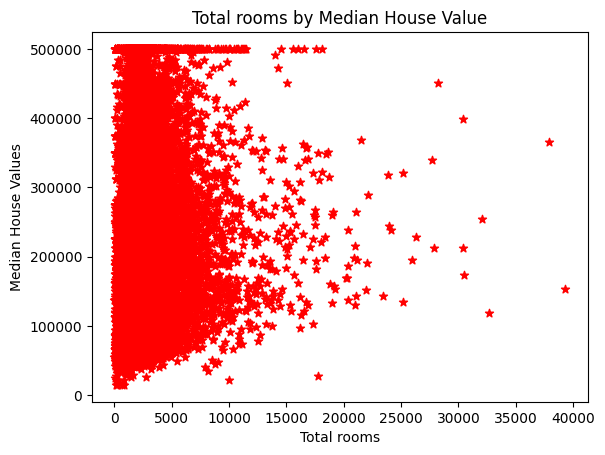

In [12]:
# Total rooms by Median House Value
x = df["total_rooms"]
y = df["median_house_value"]
plt.scatter(x, y, color = 'red', marker = '*')
plt.title("Total rooms by Median House Value")
plt.xlabel("Total rooms")
plt.ylabel("Median House Values")
plt.show()

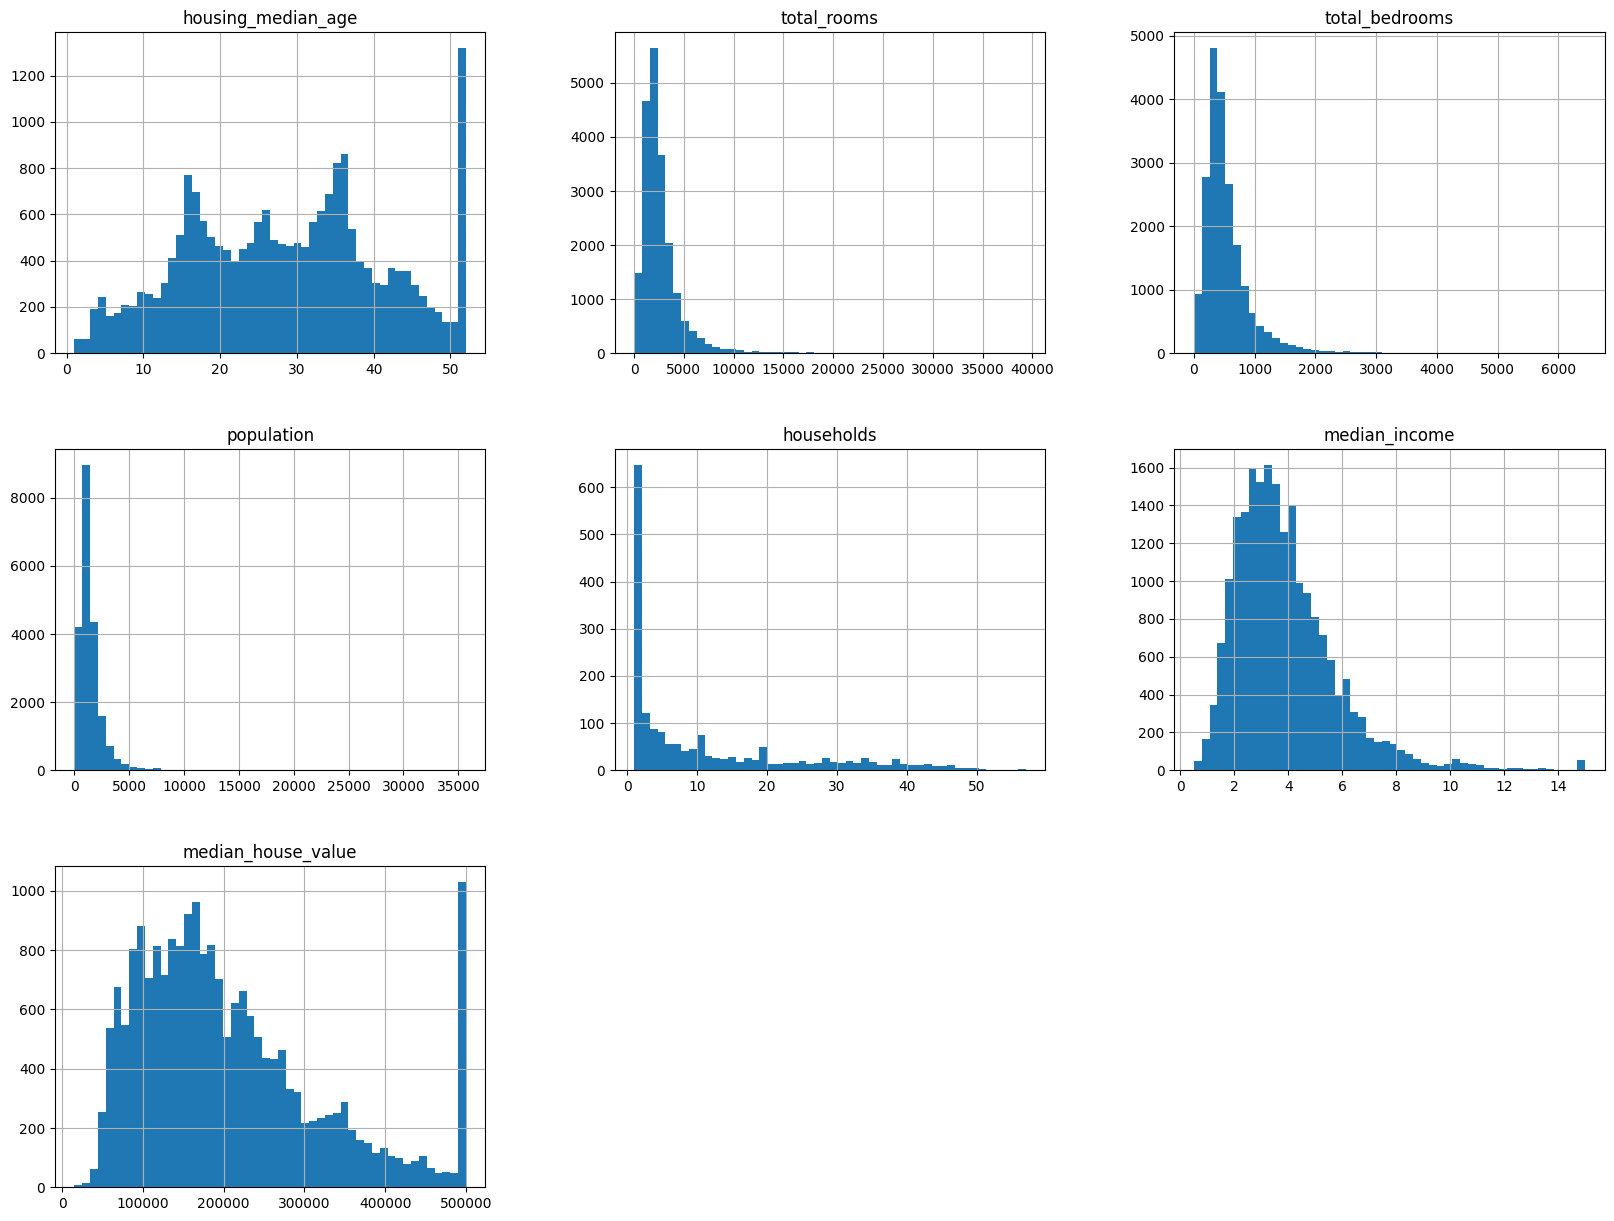

In [13]:
# Histograms for numerical features
numerical_features = ['housing_median_age', 'total_rooms', 'total_bedrooms', 
                     'population', 'households', 'median_income', 'median_house_value']

df[numerical_features].hist(bins=50, figsize=(20,15))
plt.show()

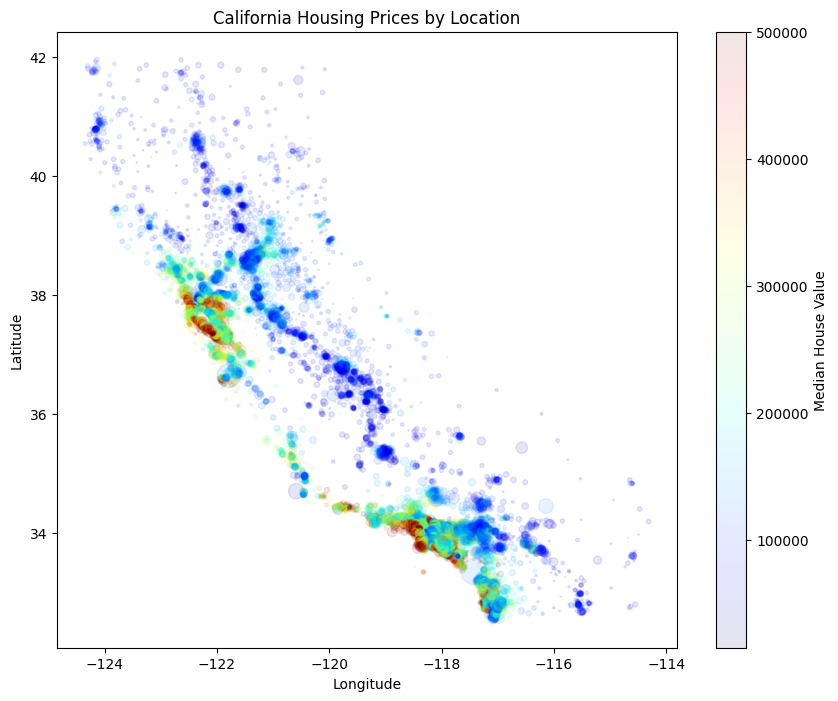

In [14]:
# Scatter plot of geographical distribution
plt.figure(figsize=(10,8))
plt.scatter(df['longitude'], df['latitude'], alpha=0.1, 
            c=df['median_house_value'], cmap='jet', 
            s=df['population']/100)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.show()

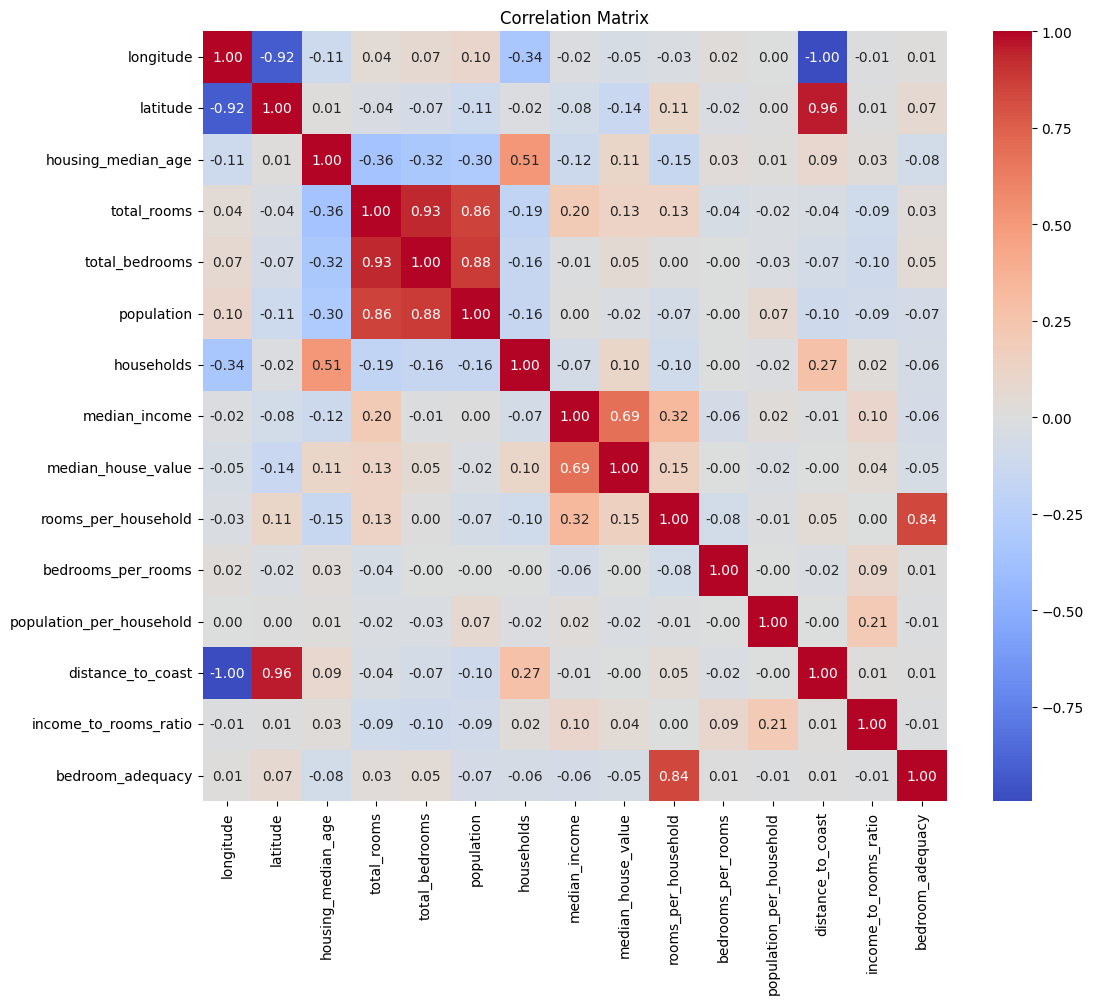


Top correlations with median_house_value:
median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151927
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.103654
total_bedrooms              0.049686
income_to_rooms_ratio       0.041348
distance_to_coast          -0.000867
bedrooms_per_rooms         -0.001395
population_per_household   -0.023265
population                 -0.024650
longitude                  -0.045967
bedroom_adequacy           -0.046739
latitude                   -0.144160
Name: median_house_value, dtype: float64


In [15]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Now calculate correlation
corr_matrix = numerical_df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Top correlations with target variable
print("\nTop correlations with median_house_value:")
print(corr_matrix['median_house_value'].sort_values(ascending=False))

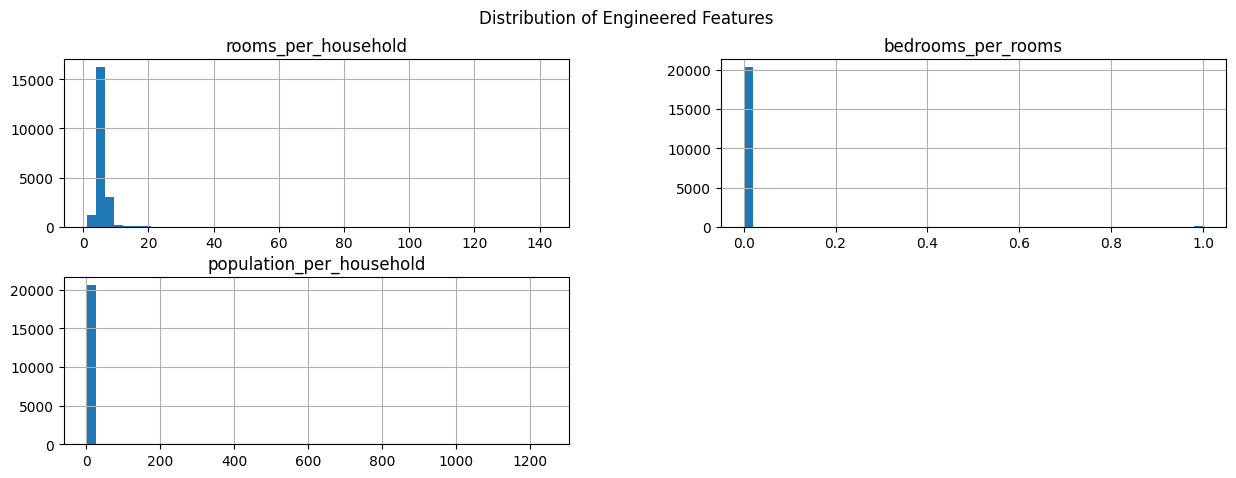


Correlation of engineered features with target:
rooms_per_household         0.151927
bedrooms_per_rooms         -0.001395
population_per_household   -0.023265
median_house_value          1.000000
Name: median_house_value, dtype: float64


In [16]:
# Analyze the new features created
engineered_features = ['rooms_per_household', 'bedrooms_per_rooms', 'population_per_household']

# Distribution of new features
df[engineered_features].hist(bins=50, figsize=(15,5))
plt.suptitle('Distribution of Engineered Features')
plt.show()

# Correlation of new features with target
print("\nCorrelation of engineered features with target:")
print(df[engineered_features + ['median_house_value']].corr()['median_house_value'])

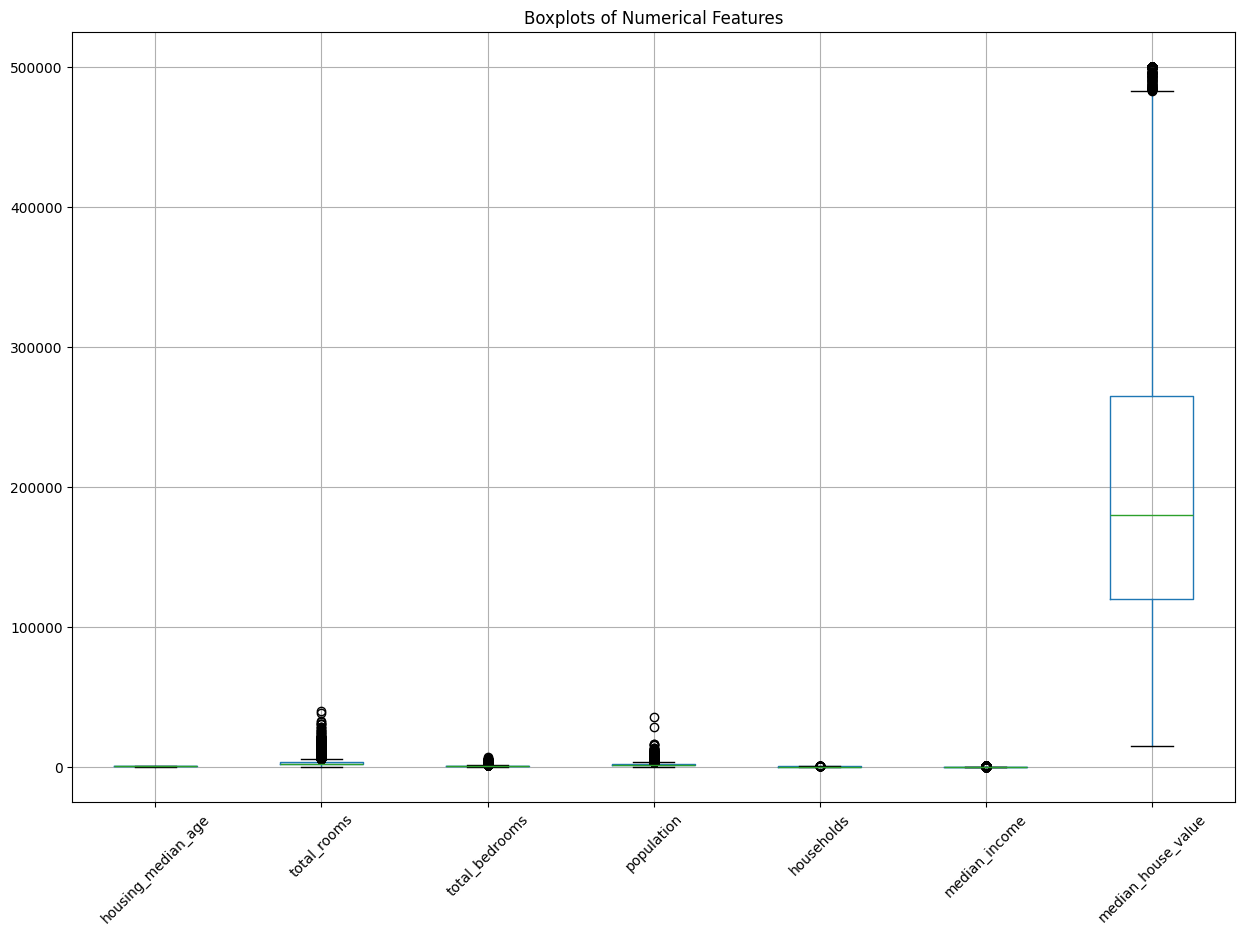

In [17]:
# Boxplots for numerical features to detect outliers
plt.figure(figsize=(15,10))
df[numerical_features].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.show()

# Model Used: Random  Forest  Regressor

In [18]:
# Prepare features and target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Define numeric features
numeric_features = [
    "total_bedrooms", "population", "total_rooms", 
    "housing_median_age", "households", "median_income",
    "rooms_per_household", "bedrooms_per_rooms", 
    "population_per_household", "distance_to_coast", 
    "income_to_rooms_ratio", "bedroom_adequacy"
]

# Define categorical features
categorical_features = ["ocean_proximity"]

# Create transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="passthrough"  # For longitude/latitude
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42
    ))
])

model.fit(X_train, y_train)

# Feature importance analysis
feature_names = (
    numeric_features + 
    list(model.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out()) +
    ['longitude', 'latitude']
)

importances = model.named_steps['regressor'].feature_importances_
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(feature_importances)

# Make predictions and evaluate
y_pred = model.predict(X_test)




Feature Importances:
                       feature  importance
5                median_income    0.522894
13      ocean_proximity_INLAND    0.153490
8     population_per_household    0.074913
18                    latitude    0.057695
9            distance_to_coast    0.045494
3           housing_median_age    0.041782
17                   longitude    0.032693
11            bedroom_adequacy    0.020281
1                   population    0.010232
0               total_bedrooms    0.009963
2                  total_rooms    0.007901
6          rooms_per_household    0.007346
10       income_to_rooms_ratio    0.007124
4                   households    0.004372
16  ocean_proximity_NEAR OCEAN    0.002524
12   ocean_proximity_<1H OCEAN    0.000905
15    ocean_proximity_NEAR BAY    0.000375
7           bedrooms_per_rooms    0.000015
14      ocean_proximity_ISLAND    0.000000


In [19]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE: ${mae:,.0f}")
print(f"R²: {r2:.2f}")

# Baseline comparisons
mean_pred = [y_train.mean()] * len(y_test)
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))

median_pred = [y_train.median()] * len(y_test)
median_rmse = np.sqrt(mean_squared_error(y_test, median_pred))

print("\nBaseline Comparisons:")
print(f"Model RMSE: ${rmse:,.0f} ({rmse/y_test.mean():.1%} of avg price)")
print(f"Mean baseline RMSE: ${mean_rmse:,.0f}")
print(f"Median baseline RMSE: ${median_rmse:,.0f}")

# Cross-validation
scores = cross_val_score(
    model, X, y,
    scoring='neg_root_mean_squared_error',
    cv=5
)
print("\nCross-Validation Results:")
print(f"Average RMSE: ${-scores.mean():,.0f} ± ${scores.std():,.0f}")

# Model performance
print("\nTraining vs Test Performance:")
print(f"Training R²: {model.score(X_train, y_train):.2f}")
print(f"Test R²: {model.score(X_test, y_test):.2f}")

# Example prediction with feature engineering
new_house = pd.DataFrame({
    "longitude": [-122.25],
    "latitude": [37.85],
    "housing_median_age": [52],
    "total_rooms": [1500],
    "total_bedrooms": [300],
    "population": [600],
    "households": [300],
    "median_income": [8.3252],
    "ocean_proximity": ["NEAR BAY"]
})

# Calculated engineered features
new_house["rooms_per_household"] = new_house["total_rooms"] / new_house["households"]
new_house["bedrooms_per_rooms"] = new_house["total_bedrooms"] / new_house["total_rooms"]
new_house["population_per_household"] = new_house["population"] / new_house["households"]
new_house["distance_to_coast"] = np.sqrt(new_house["longitude"]**2 + new_house["latitude"]**2)
new_house["income_to_rooms_ratio"] = new_house["median_income"] / new_house["total_rooms"]
new_house["bedroom_adequacy"] = new_house["total_bedrooms"] / new_house["households"]

# Ensure column order matches training data
new_house = new_house[X.columns]

predicted_price = model.predict(new_house)
print("\nExample Prediction:")
print(f"Predicted house price: ${predicted_price[0]:,.2f}")


Model Performance:
RMSE: $50,887
MAE: $32,808
R²: 0.80

Baseline Comparisons:
Model RMSE: $50,887 (24.8% of avg price)
Mean baseline RMSE: $114,486
Median baseline RMSE: $117,312

Cross-Validation Results:
Average RMSE: $70,233 ± $7,938

Training vs Test Performance:
Training R²: 0.90
Test R²: 0.80

Example Prediction:
Predicted house price: $434,087.26


In [20]:
mean_price = df["median_house_value"].mean()
std_price = df["median_house_value"].std()
print(f"Mean House Price: ${mean_price:,.2f}")
print(f"Standard Deviation: ${std_price:,.2f}")

Mean House Price: $206,855.82
Standard Deviation: $115,395.62


# Conclusion

Working on this house price prediction project helped me understand how different property features affect the market value. I went through the full data science process—from cleaning and exploring the data to building and testing models—and I can confidently say that machine learning really helps in making sense of real estate trends.

The models I built, especially the Random Forest and Linear Regression ones, gave decent predictions and can be useful in real-world cases like helping buyers know if a house is overpriced or helping agents set better price ranges.

This project showed me how important good data and the right features are in building accurate models. I’ll keep improving this by testing more algorithms, tuning parameters better, and maybe even trying deep learning later.